        CAS number                   Principal name Primary descriptor  \
0         120-51-4                  Benzyl benzoate           Balsamic   
1        7492-67-3         Citronelloxyacetaldehyde          Aldehydic   
2         104-09-6              p-Tolylacetaldehyde              Green   
3         122-84-9  1-(p-Methoxyphenyl)-2-propanone           Balsamic   
4        2408-37-9     2,2,6-Trimethylcyclohexanone             Citrus   
...            ...                              ...                ...   
3116  1009814-14-5                         Yuzunone             Fruity   
3117   102242-62-6    Zanthoxylum piperitum extract             Citrus   
3118     4221-99-2                   (S)-Butan-2-ol             Fruity   
3119       96-17-3            2-Methylbutyraldehyde           Gourmand   
3120       79-09-4                   Propionic acid             Acidic   

     Descriptor 2 Descriptor 3 Priority Date  Grant Date  Unnamed: 7  \
0          Fruity       Floral    2022-

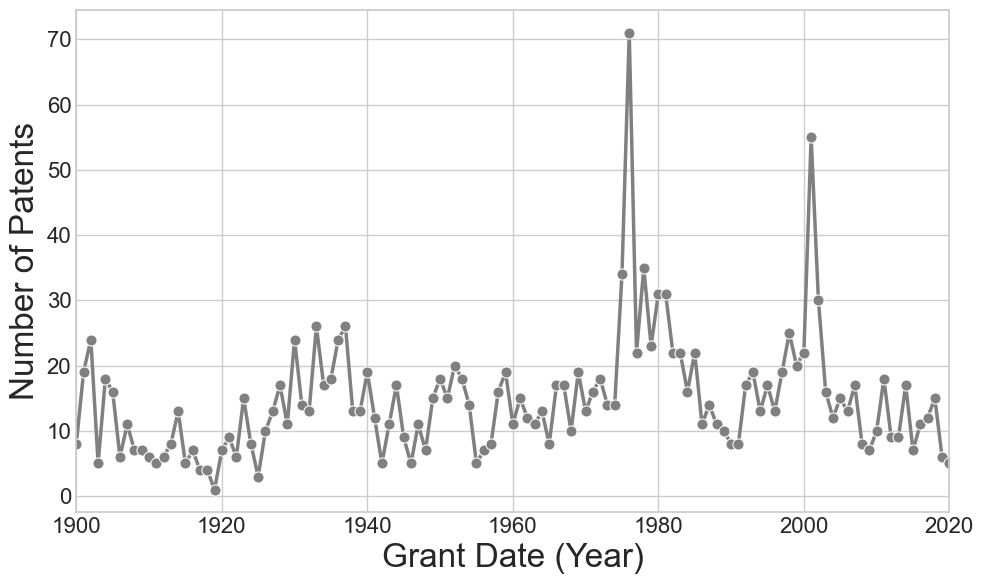

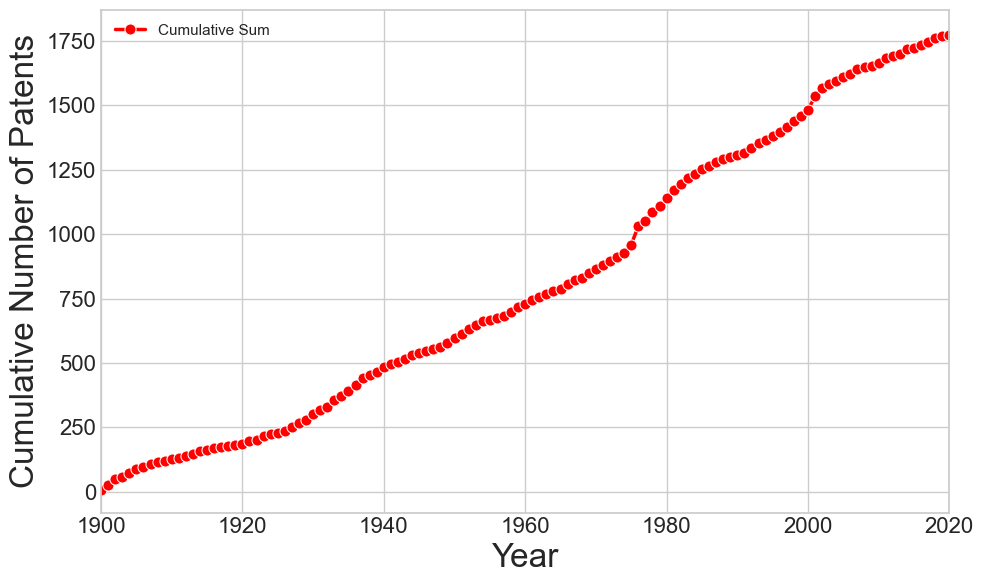

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
file_path = "../dataset/FIG.csv"  # Update this path if needed
df = pd.read_csv(file_path)
print(df)
# Extract year from the 'Grant Date' column (assuming format YYYY-MM-DD)
df['Year'] = pd.to_datetime(df['Grant Date'], errors='coerce').dt.year

# Count occurrences per year and compute cumulative sum
year_counts = df['Year'].value_counts().sort_index()
cumulative_counts = year_counts.cumsum()

# Set seaborn theme (using a whitegrid style similar to your example)
sns.set_theme(style="whitegrid")

###############################################################################
# Plot 1: Number of Patents per Year
###############################################################################
plt.figure(figsize=(10, 6))
# Seaborn lineplot for patent counts
sns.lineplot(x=year_counts.index, y=year_counts.values,
             marker='o', linewidth=2.5, markersize=8, color='gray')

plt.xlabel("Grant Date (Year)", fontsize=24)
plt.ylabel("Number of Patents", fontsize=24)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)

# Customize tick parameters similar to your figure
plt.tick_params(axis='both', which='major', direction='in', length=8, width=1.5)
plt.tick_params(axis='both', which='minor', direction='in', length=4, width=1.0)
plt.xlim(1900,2020)

plt.tight_layout()
# plt.savefig("../output/Patents_per_year.svg", format="svg", dpi=300)
plt.show()

###############################################################################
# Plot 2: Cumulative Number of Patents Over Time
###############################################################################
plt.figure(figsize=(10, 6))
sns.lineplot(x=cumulative_counts.index, y=cumulative_counts.values,
             marker='o', linewidth=2.5, markersize=8, color='red', label='Cumulative Sum')

plt.xlabel("Year", fontsize=24)
plt.ylabel("Cumulative Number of Patents", fontsize=24)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.tick_params(axis='both', which='major', direction='in', length=8, width=1.5)
plt.tick_params(axis='both', which='minor', direction='in', length=4, width=1.0)
plt.legend(frameon=False)
plt.xlim(1900,2020)

plt.tight_layout()
# plt.savefig("../output/Cumulative_Patents.svg", format="svg", dpi=300)
plt.show()


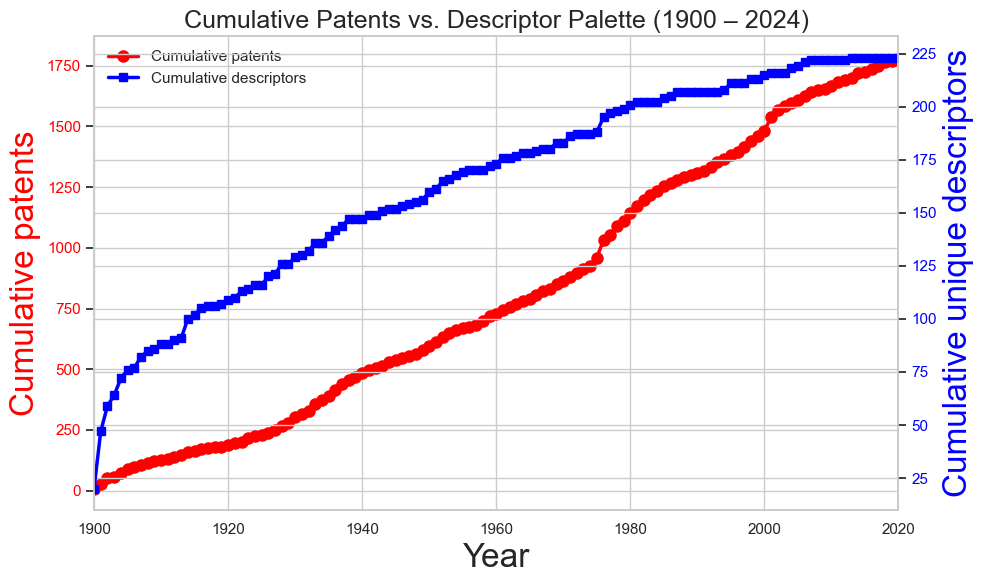

In [2]:
# ------------------------------------------------------------------
# 1)  Collect every descriptor string in the three columns
# ------------------------------------------------------------------
# Helper: split on comma/semicolon and strip whitespace
def extract_terms(cell):
    if pd.isna(cell):
        return []
    return [t.strip() for part in str(cell).split(';')     # allow “;” lists
                       for t in part.split(',')            # allow “,” lists
                       if t.strip()]

# Build a long Series of (descriptor, grant_year)
rows = []
for _, row in df.iterrows():
    yr = pd.to_datetime(row['Grant Date'], errors='coerce').year
    if pd.isna(yr):
        continue
    for col in ['Primary descriptor', 'Descriptor 2', 'Descriptor 3']:
        for term in extract_terms(row[col]):
            rows.append({'descriptor': term, 'year': int(yr)})

desc_df = pd.DataFrame(rows)

# ------------------------------------------------------------------
# 2)  Year each descriptor first appears, then cumulative palette
# ------------------------------------------------------------------
first_year = (desc_df.groupby('descriptor')['year']
                        .min()
                        .reset_index())

new_desc = (first_year['year']
            .value_counts()
            .sort_index()
            .reindex(range(1900, 2025), fill_value=0))

cum_desc = new_desc.cumsum()              # cumulative unique descriptors

# ------------------------------------------------------------------
# 3)  Overlay on your cumulative-patent plot
# ------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(10, 6))

# existing curve: cumulative patents
ax1.plot(cumulative_counts.index, cumulative_counts.values,
         marker='o', linewidth=2.5, markersize=8,
         color='red', label='Cumulative patents')
ax1.set_xlabel("Year", fontsize=24)
ax1.set_ylabel("Cumulative patents", fontsize=24, color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_xlim(1900, 2020)

# second axis: cumulative descriptors
ax2 = ax1.twinx()
ax2.plot(cum_desc.index, cum_desc.values,
         marker='s', linewidth=2.5, markersize=6,
         color='blue', label='Cumulative descriptors')
ax2.set_ylabel("Cumulative unique descriptors", fontsize=24, color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# combined legend
lns1, lbls1 = ax1.get_legend_handles_labels()
lns2, lbls2 = ax2.get_legend_handles_labels()
ax1.legend(lns1 + lns2, lbls1 + lbls2, frameon=False, loc='upper left')

plt.title("Cumulative Patents vs. Descriptor Palette (1900 – 2024)", fontsize=18)
plt.tight_layout()
plt.savefig("../output/Cumulative_Patents_and_Descriptors.svg", format="svg", dpi=300)
plt.show()


==== CORRELATION SUMMARY ====
Levels  – Spearman   notes vs patents:  ρ=1.000, p=0
Levels  – Spearman descriptors vs patents:  ρ=0.999, p=1.09e-179
Logs    – Pearson    notes vs patents:  r=0.952, p=2.78e-65, β=1.47
Logs    – Pearson descriptors vs patents: r=0.990, p=5.35e-107, β=0.37
Diffs   – Spearman   Δnotes vs Δpatents: ρ=0.122, p=0.177
Diffs   – Spearman   Δdesc  vs Δpatents: ρ=0.264, p=0.00303


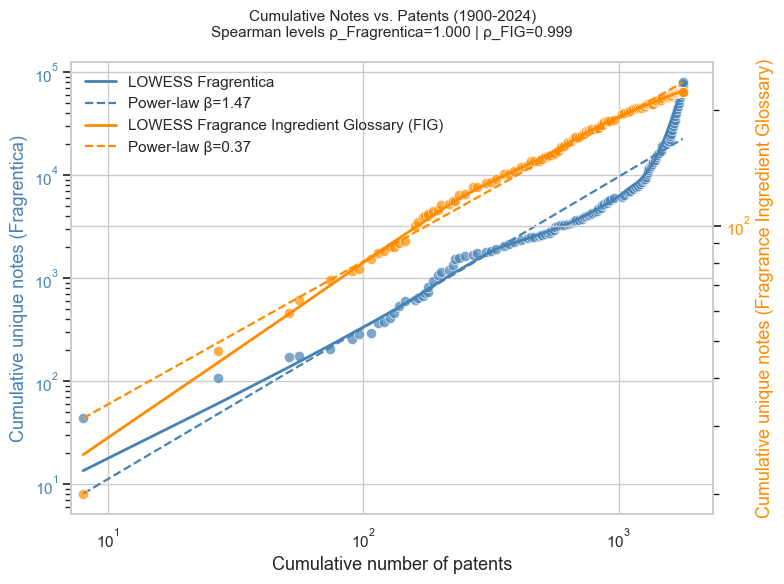

In [3]:
#!/usr/bin/env python
"""
Extended analysis of fragrance-related patents vs. perfume vocabulary

Creates a log–log twin-axis scatter plot with:
  • Ordinary-least-squares *power-law* fits (dashed lines)
  • LOWESS curves (solid smoothed curves)
  • Spearman rank correlations on levels
  • Pearson correlations on log-transformed data (= power-law fit)
  • Spearman correlations on year-to-year *changes*

Saves figure to ../output/Patents_Notes_Descriptors_loglog.svg
Prints all correlation statistics to stdout.
"""
# ----------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from statsmodels.nonparametric.smoothers_lowess import lowess

sns.set_theme(style="whitegrid")

# ----------------------------------------------------------------------
# CONFIG  – update paths if needed
# ----------------------------------------------------------------------
PATENT_CSV   = "../dataset/FIG.csv"      # file with “Grant Date”
PERFUME_CSV  = "../dataset/perfume_dataset.csv"        # file with accord / notes
YEAR_START, YEAR_END = 1900, 2024
OUT_DIR   = "../output"
OUT_FIG   = "Patents_Notes_Descriptors_loglog.svg"
os.makedirs(OUT_DIR, exist_ok=True)

# ======================================================================
# 1│  C U M U L A T I V E   P A T E N T S
# ======================================================================
pat = pd.read_csv(PATENT_CSV)
pat['year'] = pd.to_datetime(pat['Grant Date'], errors='coerce').dt.year
year_counts = (pat['year']
               .dropna()
               .astype(int)
               .value_counts()
               .sort_index()
               .reindex(range(YEAR_START, YEAR_END + 1), fill_value=0))
cum_patents = year_counts.cumsum()

# ======================================================================
# 2│  C U M U L A T I V E   N O T E S   ( A C C O R D S )
# ======================================================================
perf = pd.read_csv(PERFUME_CSV)
perf['year'] = pd.to_numeric(perf['year'], errors='coerce')
perf = perf.dropna(subset=['year'])
perf = perf[(perf['year'] >= YEAR_START) & (perf['year'] <= YEAR_END)]
perf['year'] = perf['year'].astype(int)

def split_terms(cell):
    if pd.isna(cell):
        return []
    return [t.strip() for seg in str(cell).split(';') for t in seg.split(',') if t.strip()]

for col in ('note_list', 'accord', 'notes'):
    if col in perf.columns:
        note_col = col
        break
else:
    raise ValueError("No note/accord column in perfume dataset")

if perf[note_col].apply(lambda x: isinstance(x, list)).all():
    perf['note_list'] = perf[note_col]
else:
    perf['note_list'] = perf[note_col].apply(split_terms)

note_rows = [{'year': r.year, 'note': n} for _, r in perf.iterrows() for n in r.note_list]
note_df   = pd.DataFrame(note_rows)

first_note_year = note_df.groupby('note')['year'].min()
new_notes = (first_note_year
             .value_counts()
             .sort_index()
             .reindex(range(YEAR_START, YEAR_END + 1), fill_value=0))
cum_notes = new_notes.cumsum()

# ======================================================================
# 3│  C U M U L A T I V E   D E S C R I P T O R   P A L E T T E
# ======================================================================
desc_rows = []
for _, row in pat.iterrows():
    yr = row['year']
    if np.isnan(yr):
        continue
    for col in ('Primary descriptor', 'Descriptor 2', 'Descriptor 3'):
        if col in row and not pd.isna(row[col]):
            for term in split_terms(row[col]):
                desc_rows.append({'descriptor': term, 'year': int(yr)})

desc_df = pd.DataFrame(desc_rows)
if desc_df.empty:
    raise ValueError("No descriptor columns found in the patent file")

first_desc_year = desc_df.groupby('descriptor')['year'].min()
new_desc = (first_desc_year
            .value_counts()
            .sort_index()
            .reindex(range(YEAR_START, YEAR_END + 1), fill_value=0))
cum_desc = new_desc.cumsum()

# ======================================================================
# 4│  A L I G N   S E R I E S
# ======================================================================
aligned = pd.DataFrame({
    'patents'    : cum_patents,
    'notes'      : cum_notes.replace(0, np.nan),
    'descriptors': cum_desc.replace(0, np.nan)
}).dropna()

# ======================================================================
# 5│  C O R R E L A T I O N S   &   P O W E R - L A W   F I T S
# ======================================================================
# ---- Spearman on levels
rho_notes, p_notes = spearmanr(aligned['patents'], aligned['notes'])
rho_desc , p_desc  = spearmanr(aligned['patents'], aligned['descriptors'])

# ---- Pearson on log–log (power-law elasticity)
log_pat  = np.log10(aligned['patents'])
log_note = np.log10(aligned['notes'])
log_desc = np.log10(aligned['descriptors'])

r_log_notes,  p_log_notes  = pearsonr(log_pat, log_note)
r_log_desc ,  p_log_desc   = pearsonr(log_pat, log_desc)

β_notes, α_notes = np.polyfit(log_pat, log_note, 1)  # note = 10^α * patents^β
β_desc , α_desc  = np.polyfit(log_pat, log_desc, 1)

# ---- Spearman on year-to-year changes
diffs = aligned.diff().dropna()
rho_d_notes, p_d_notes = spearmanr(diffs['patents'], diffs['notes'])
rho_d_desc , p_d_desc  = spearmanr(diffs['patents'], diffs['descriptors'])

# Print summary
print("==== CORRELATION SUMMARY ====")
print(f"Levels  – Spearman   notes vs patents:  ρ={rho_notes:.3f}, p={p_notes:.3g}")
print(f"Levels  – Spearman descriptors vs patents:  ρ={rho_desc:.3f}, p={p_desc:.3g}")
print(f"Logs    – Pearson    notes vs patents:  r={r_log_notes:.3f}, p={p_log_notes:.3g}, β={β_notes:.2f}")
print(f"Logs    – Pearson descriptors vs patents: r={r_log_desc :.3f}, p={p_log_desc :.3g}, β={β_desc :.2f}")
print(f"Diffs   – Spearman   Δnotes vs Δpatents: ρ={rho_d_notes:.3f}, p={p_d_notes:.3g}")
print(f"Diffs   – Spearman   Δdesc  vs Δpatents: ρ={rho_d_desc :.3f}, p={p_d_desc :.3g}")

# ======================================================================
# 6│  P L O T   ( log-log  twin y-axes )
# ======================================================================
fig, ax_left = plt.subplots(figsize=(8, 6))

# ----- scatter + LOWESS for notes (left axis)
sns.scatterplot(x='patents', y='notes', data=aligned,
                color='steelblue', alpha=0.7, s=55, ax=ax_left)
lowess_left = lowess(np.log10(aligned['notes']), np.log10(aligned['patents']),
                     frac=0.3, return_sorted=True)
ax_left.plot(10**lowess_left[:, 0], 10**lowess_left[:, 1],
             color='steelblue', linewidth=2,
             label='LOWESS Fragrentica')

# ----- dashed power-law line (notes)
x_line = np.linspace(log_pat.min(), log_pat.max(), 200)
ax_left.plot(10**x_line, 10**(α_notes + β_notes * x_line),
             linestyle='--', color='steelblue', linewidth=1.6,
             label=f'Power-law β={β_notes:.2f}')

ax_left.set_xlabel("Cumulative number of patents", fontsize=13)
ax_left.set_ylabel("Cumulative unique notes (Fragrentica)", fontsize=13, color='steelblue')
ax_left.tick_params(axis='y', labelcolor='steelblue')

# ----- right axis for descriptors
ax_right = ax_left.twinx()
sns.scatterplot(x='patents', y='descriptors', data=aligned,
                color='darkorange', alpha=0.7, s=55, ax=ax_right)
lowess_right = lowess(np.log10(aligned['descriptors']),
                      np.log10(aligned['patents']),
                      frac=0.3, return_sorted=True)
ax_right.plot(10**lowess_right[:, 0], 10**lowess_right[:, 1],
              color='darkorange', linewidth=2,
              label='LOWESS Fragrance Ingredient Glossary (FIG)')
ax_right.plot(10**x_line, 10**(α_desc + β_desc * x_line),
              linestyle='--', color='darkorange', linewidth=1.6,
              label=f'Power-law β={β_desc:.2f}')
ax_right.set_ylabel("Cumulative unique notes (Fragrance Ingredient Glossary)", fontsize=13,
                    color='darkorange')
ax_right.tick_params(axis='y', labelcolor='darkorange')

# ----- log scales
for ax in (ax_left, ax_right):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(left=aligned['patents'].min()*0.9)

# ----- legends
h_left,  l_left  = ax_left.get_legend_handles_labels()
h_right, l_right = ax_right.get_legend_handles_labels()
ax_left.legend(h_left + h_right, l_left + l_right,
               frameon=False, loc='upper left')

# ----- title
title  = "Cumulative Notes vs. Patents (1900-2024)\n"
title += f"Spearman levels ρ_Fragrentica={rho_notes:.3f} | ρ_FIG={rho_desc:.3f}\n"
# title += f"Power-law β_notes={β_notes:.2f}, β_desc={β_desc:.2f}"
ax_left.set_title(title, fontsize=11)

plt.tight_layout()
# plt.savefig(os.path.join(OUT_DIR, OUT_FIG), format="svg", dpi=300)
plt.show()


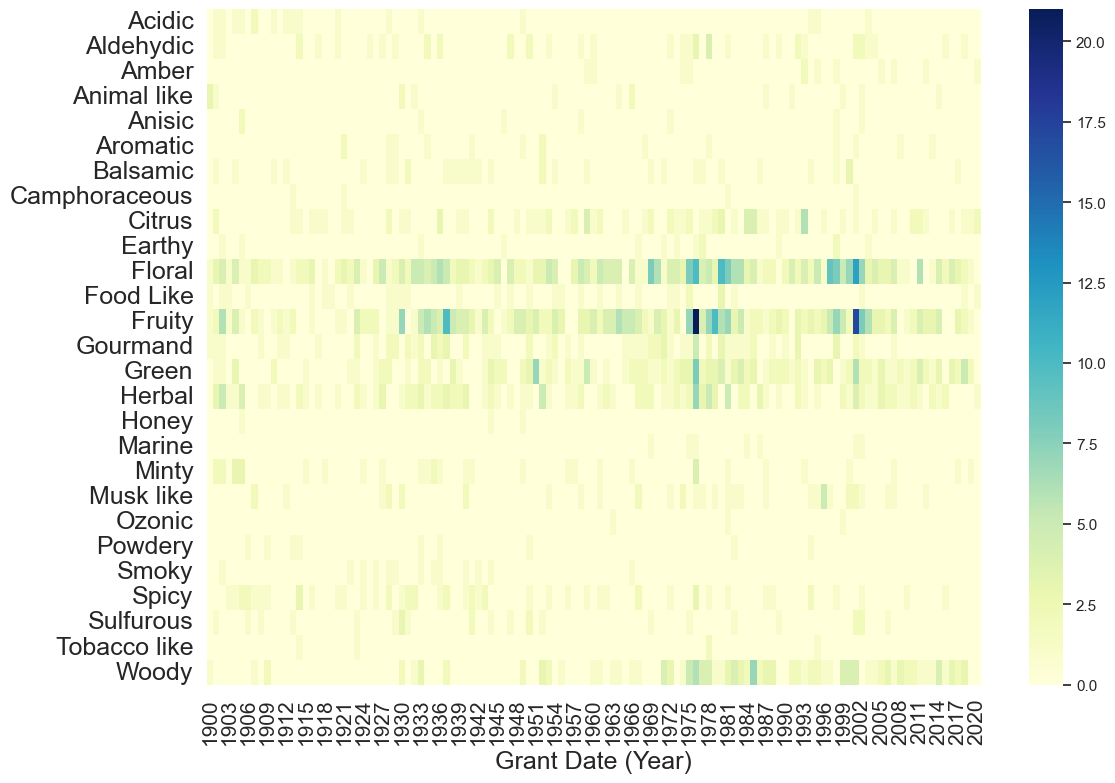

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
file_path = "../dataset/FIG.csv"  # Update if necessary
df = pd.read_csv(file_path)

# Extract year from the 'Grant Date' column
df['Year'] = pd.to_datetime(df['Grant Date'], errors='coerce').dt.year

# Filter the data to only include years up to 2020
df = df[df['Year'] <= 2020]

# Count occurrences of each Primary Descriptor per Year
heatmap_data = df.pivot_table(index='Primary descriptor', columns='Year', aggfunc='size', fill_value=0)

# Convert the column labels to integers to remove the .0 from the year labels
heatmap_data.columns = heatmap_data.columns.astype(int)

# Set a seaborn theme for consistent styling
sns.set_theme(style="white")

# Plot the heatmap using a better colormap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=0.0, annot=False, fmt="d")
plt.ylabel("", fontsize=1)
plt.xlabel("Grant Date (Year)", fontsize=18)
plt.xticks(rotation=90, fontsize=15)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.savefig("../output/Patent_heatmap.svg", format="svg", dpi=300)

plt.show()
